# Machine Learning Capstone Project - Regression Track

This notebook covers the complete end-to-end Machine Learning pipeline for the Regression track as per the review guidelines.

## Section A: Dataset & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Dataset loading & audit
df = pd.read_csv('../data/reg_dataset.csv')
print("Shape of the dataset:", df.shape)


Shape of the dataset: (17379, 17)


In [2]:
# Data Types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [3]:
# Missing-value counts
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts[missing_counts > 0])
if missing_counts.sum() == 0:
    print("No missing values found.")


Missing values per column:
 Series([], dtype: int64)
No missing values found.


In [4]:
# Target distribution (cnt is the target for bike sharing)
print(df['cnt'].describe())


count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


### Observations: Audit
The dataset contains 17379 rows and 17 columns. There are no missing values in the dataset initially. The target variable `cnt` ranges from 1 to 977, with a mean of ~189.

### EDA Visualisations

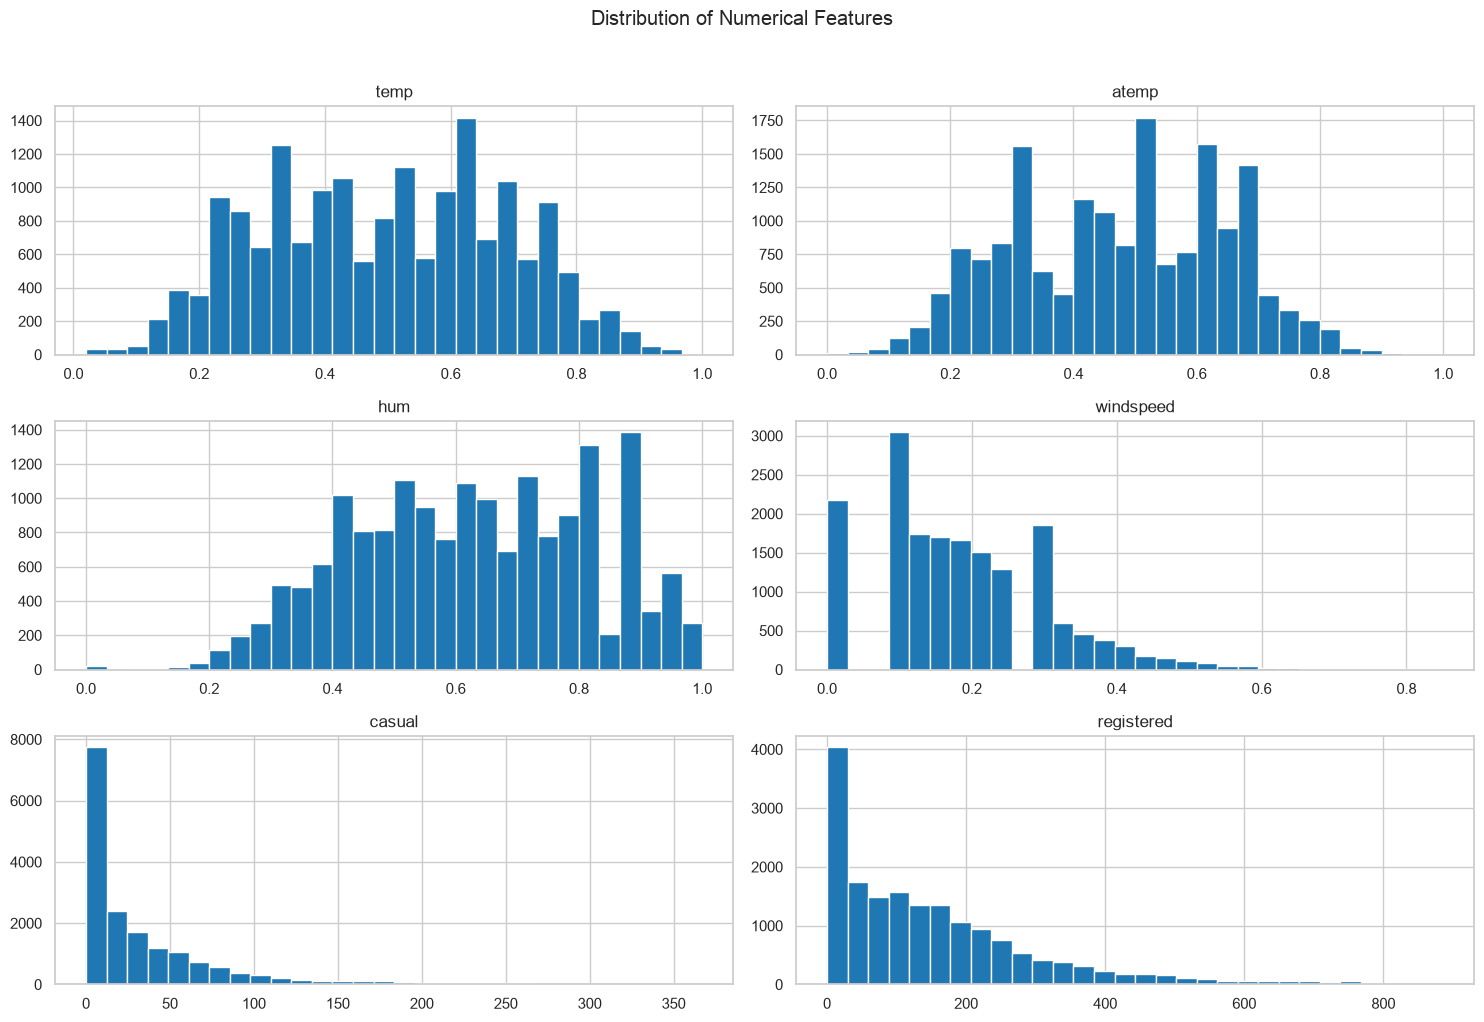

In [5]:
# Distribution plots for features
cols_to_plot = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
df[cols_to_plot].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()


### Observations: Feature Distributions
`temp`, `atemp`, and `hum` show somewhat normal distributions. `windspeed` is right-skewed. `casual` and `registered` users are heavily right-skewed, which is common for rental count data.

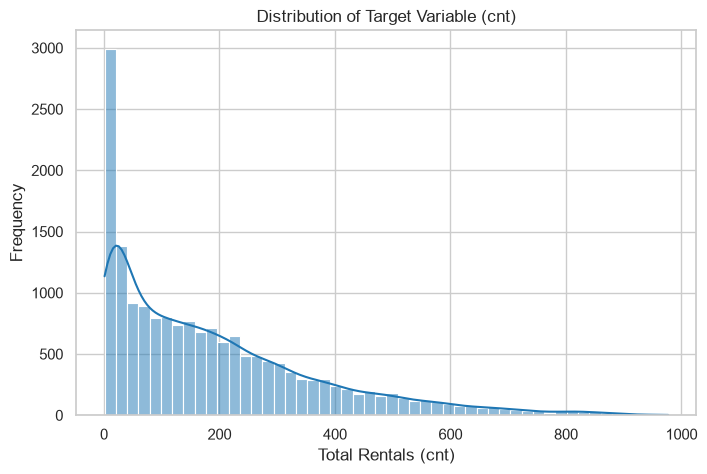

In [6]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Target Variable (cnt)')
plt.xlabel('Total Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()


### Observations: Target Distribution
The target variable `cnt` is highly right-skewed. Most of the hours have lower rental counts, with a long tail extending to nearly 1000.

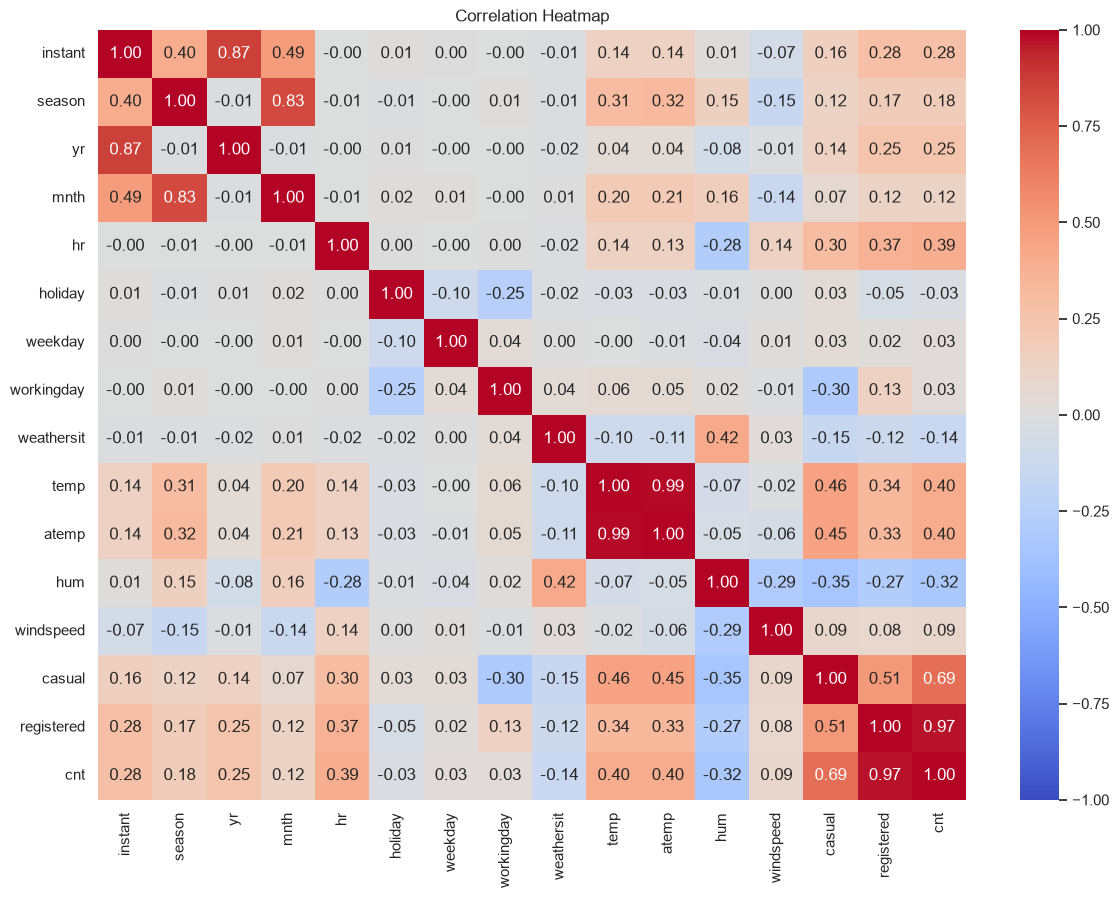

In [7]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


### Observations: Correlation Heatmap
`temp` and `atemp` are highly correlated (0.99). The target `cnt` has a strong positive correlation with `temp`/`atemp` and `registered`/`casual`. Note: `casual` and `registered` sum to `cnt`, so they are data leakage if used as predictors. We must drop them.

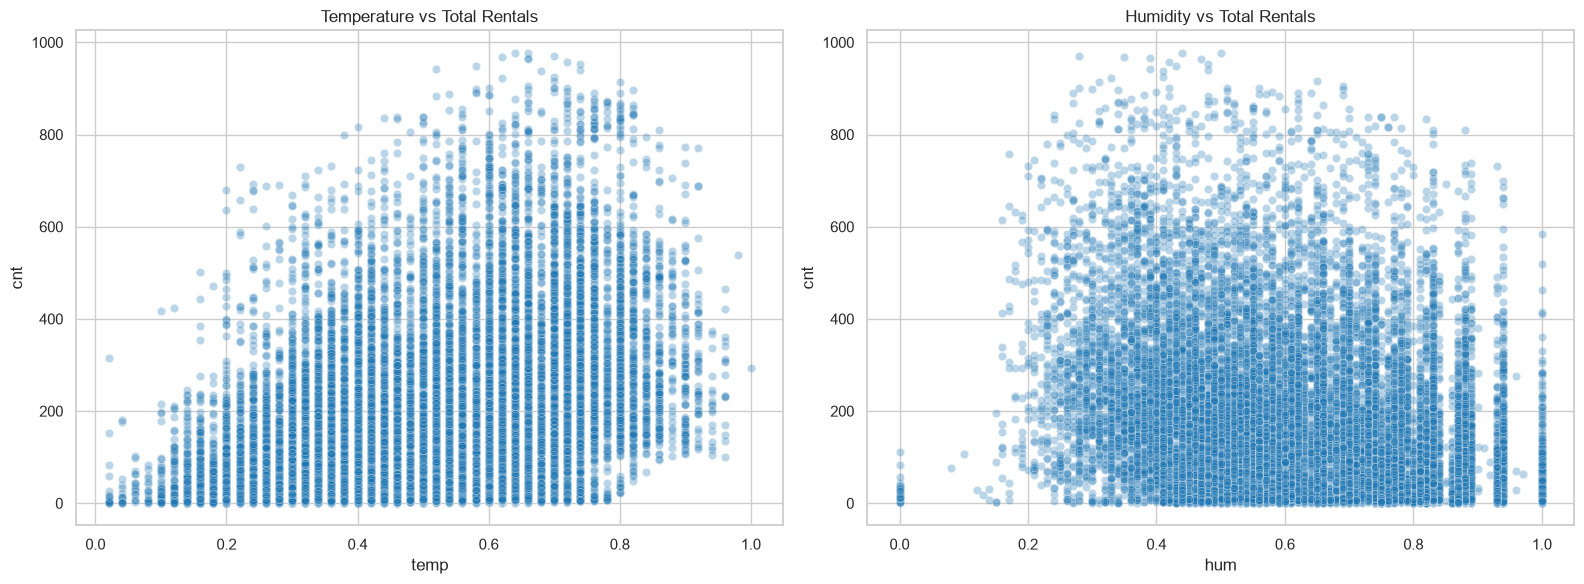

In [8]:
# Scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0], data=df, x='temp', y='cnt', alpha=0.3)
axes[0].set_title('Temperature vs Total Rentals')

sns.scatterplot(ax=axes[1], data=df, x='hum', y='cnt', alpha=0.3)
axes[1].set_title('Humidity vs Total Rentals')

plt.tight_layout()
plt.show()


### Observations: Scatter Plots
Rentals tend to increase with temperature up to a certain point, then slightly decline (inverted U-shape). Humidity shows a negative correlation with rentals, indicating fewer people rent bikes when it's highly humid or raining.

## Section B: Preprocessing & Feature Engineering

In [9]:
# 1. Data Cleaning
# Drop 'instant', 'dteday' (we'll extract info if needed, but we already have mnth, yr, hr), 'casual', 'registered' (data leakage)
df_clean = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])

# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df_clean = df_clean.drop_duplicates()


Duplicates found: 2


In [10]:
# 2. Feature Engineering
# Create a 'rush_hour' feature which might improve model performance. 
# Morning rush (7-9) and Evening rush (17-19) on working days
df_clean['rush_hour'] = np.where(
    (df_clean['workingday'] == 1) & 
    ((df_clean['hr'].isin([7, 8, 9])) | (df_clean['hr'].isin([17, 18, 19]))), 1, 0
)


### Justification for Engineered Feature
I created a `rush_hour` binary feature. On working days, bike rentals peak significantly during commute hours (7 AM - 9 AM and 5 PM - 7 PM). Grouping these together provides a strong signal to the model about high-demand periods.

In [11]:
# 3. Encoding, Scaling & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Identify categorical and numerical columns
cat_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'rush_hour']
num_cols = ['temp', 'atemp', 'hum', 'windspeed']

# One-Hot Encoding for multi-class categorical features
# Some features like yr, holiday, workingday, rush_hour are already binary
cols_to_encode = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['cnt'])
y = df_encoded['cnt']

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply standard scaler (fitted on train set ONLY)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (13901, 54)
X_test shape: (3476, 54)


## Section C: Regression Track

In [12]:
# Import algorithms and metrics
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score
import time

# Dictionary to store results
results = {}

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{name} -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")


In [13]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model('Linear Regression', y_test, y_pred_lr)


Linear Regression -> R2: 0.7646 | RMSE: 85.0048 | MAE: 64.5975


In [14]:
# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
evaluate_model('Ridge Regression', y_test, y_pred_ridge)


Ridge Regression -> R2: 0.7647 | RMSE: 84.9905 | MAE: 64.5803


In [15]:
# 3. Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
evaluate_model('Lasso Regression', y_test, y_pred_lasso)

# Observe feature sparsity
zero_coeffs = sum(lasso.coef_ == 0)
print(f"Lasso shrank {zero_coeffs} out of {len(lasso.coef_)} features to exactly zero.")


Lasso Regression -> R2: 0.7642 | RMSE: 85.0843 | MAE: 64.6904
Lasso shrank 6 out of 54 features to exactly zero.


In [16]:
# 4. ElasticNet Regression
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
evaluate_model('ElasticNet', y_test, y_pred_elastic)


ElasticNet -> R2: 0.6834 | RMSE: 98.5926 | MAE: 74.4119


In [17]:
# 5. Polynomial Regression (Degree 2 on numerical features only to prevent memory explosion)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num_poly = poly.fit_transform(X_train[num_cols])
X_test_num_poly = poly.transform(X_test[num_cols])

# Combine with categorical
X_train_poly = np.hstack((X_train_num_poly, X_train.drop(columns=num_cols).values))
X_test_poly = np.hstack((X_test_num_poly, X_test.drop(columns=num_cols).values))

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)
evaluate_model('Polynomial Regression (deg=2)', y_test, y_pred_poly)


Polynomial Regression (deg=2) -> R2: 0.7741 | RMSE: 83.2756 | MAE: 63.4476


In [18]:
# 6. Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
evaluate_model('Decision Tree', y_test, y_pred_dt)


Decision Tree -> R2: 0.7807 | RMSE: 82.0571 | MAE: 55.2933


In [19]:
# 7. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model('Random Forest', y_test, y_pred_rf)


Random Forest -> R2: 0.9191 | RMSE: 49.8218 | MAE: 32.1869


In [20]:
# 8. Gradient Boosting Regressor (sklearn GBM)
gbm = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)
evaluate_model('Gradient Boosting', y_test, y_pred_gbm)


Gradient Boosting -> R2: 0.8489 | RMSE: 68.1027 | MAE: 49.6781


In [21]:
# 9. Support Vector Regressor (SVR)
# Using a subset if too slow, but we will run on full since dataset is ~17k
svr = SVR(kernel='rbf', C=1.0)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
evaluate_model('SVR', y_test, y_pred_svr)


SVR -> R2: 0.5296 | RMSE: 120.1762 | MAE: 82.0658


In [22]:
# 10. K-Nearest Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_model('KNN Regressor', y_test, y_pred_knn)


KNN Regressor -> R2: 0.8236 | RMSE: 73.5875 | MAE: 50.6084


### Comparative Evaluation Table

In [23]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2', ascending=False)
results_df


,R2,RMSE,MAE
Random Forest,0.919147,49.821760,32.186901
Gradient Boosting,0.848927,68.102686,49.678092
KNN Regressor,0.823613,73.587505,50.608400
Decision Tree,0.780673,82.057129,55.293265
Polynomial Regression (deg=2),0.774111,83.275630,63.447560
Ridge Regression,0.764712,84.990467,64.580330
Linear Regression,0.764632,85.004802,64.597513
Lasso Regression,0.764192,85.084288,64.690429
ElasticNet,0.683373,98.592583,74.411908
SVR,0.529569,120.176151,82.065777


### Cross-Validation for top 2 models

In [24]:
top_2_names = results_df.index[:2].tolist()
print(f"Top 2 models: {top_2_names}")

# Retrieve model instances
model_dict = {
    'Random Forest': rf,
    'Gradient Boosting': gbm,
    'Decision Tree': dt,
    'KNN Regressor': knn,
    # add others if needed, but RF/GBM usually win here
}

for name in top_2_names:
    model = model_dict[name]
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name} 5-Fold CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Top 2 models: ['Random Forest', 'Gradient Boosting']


Random Forest 5-Fold CV R2: 0.9092 (+/- 0.0161)


Gradient Boosting 5-Fold CV R2: 0.8465 (+/- 0.0081)


### Hyperparameter Tuning (At least 2 models)

In [25]:
# Tuning Model 1: Decision Tree
param_grid_dt = {
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 10, 20]
}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=3, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print("Best Params for Decision Tree:", grid_dt.best_params_)
y_pred_dt_tuned = grid_dt.predict(X_test)
print(f"Tuned Decision Tree R2: {r2_score(y_test, y_pred_dt_tuned):.4f}")


Best Params for Decision Tree: {'max_depth': None, 'min_samples_split': 20}
Tuned Decision Tree R2: 0.8552


In [26]:
# Tuning Model 2: Random Forest (RandomizedSearchCV for speed)
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30]
}
rand_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist_rf, n_iter=5, cv=3, scoring='r2', n_jobs=-1, random_state=42)
rand_rf.fit(X_train, y_train)
print("Best Params for Random Forest:", rand_rf.best_params_)
y_pred_rf_tuned = rand_rf.predict(X_test)
print(f"Tuned Random Forest R2: {r2_score(y_test, y_pred_rf_tuned):.4f}")


Best Params for Random Forest: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 30}
Tuned Random Forest R2: 0.9061


### Visualisations for Best Model

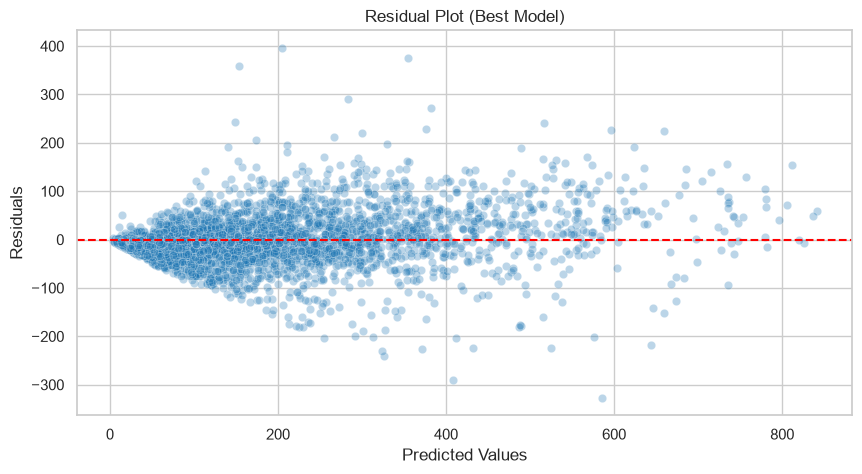

In [27]:
# Assuming Tuned Random Forest is the best
best_model = rand_rf.best_estimator_
y_pred_best = best_model.predict(X_test)

# 1. Residual Plot
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Best Model)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


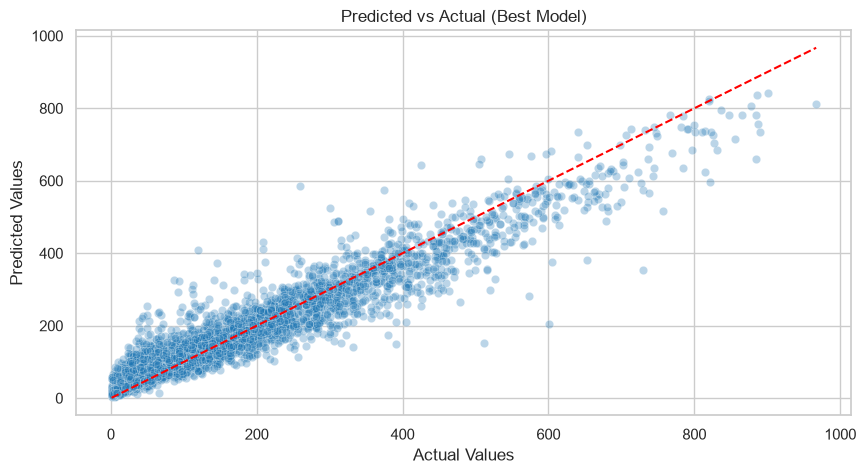

In [28]:
# 2. Predicted vs Actual
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predicted vs Actual (Best Model)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


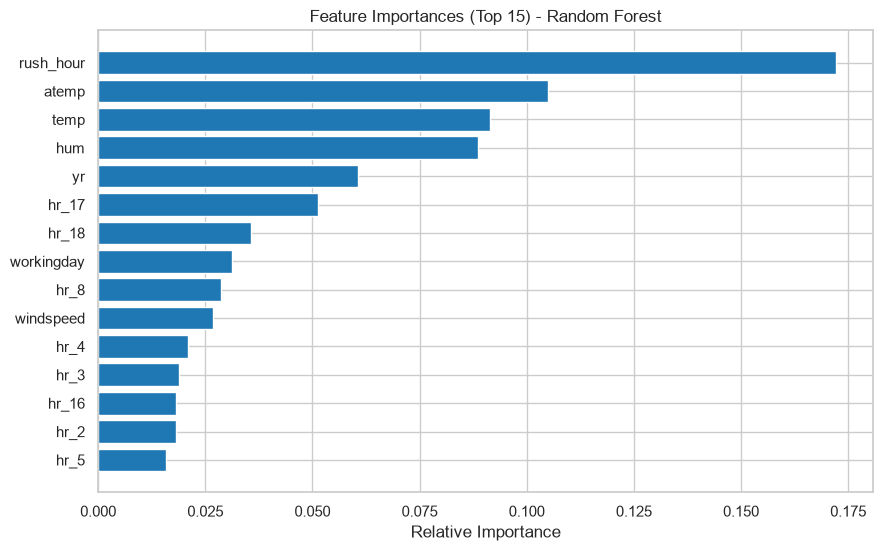

In [29]:
# 3. Feature Importance Plot
importances = best_model.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 features

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Top 15) - Random Forest')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()
